# Проект. Часть 1

## HR Analytics: Employee Attrition & Performance

Источник: Kaggle https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/data

Описание: Датасет создан специалистами IBM и представляет собой синтетические (но реалистичные) HR-данные о 1470 сотрудниках компании. Он содержит демографические характеристики, показатели удовлетворённости, данные о доходах, карьерных параметрах и информацию о том, покинул ли сотрудник компанию (всего 35 колонок).

### Описание переменных

- Age: Возраст сотрудника (от 18 до 60 лет, медиана 36) — количественная
- Attrition: Факт ухода сотрудника из компании (Yes / No) — категориальная (бинарная)
- BusinessTravel: Частота командировок (Non-Travel / Travel_Rarely / Travel_Frequently) — категориальная (номинальная)
- *DailyRate: Ежедневная ставка, числовое значение (102–1499) — количественная*
- Department: Отдел (Sales / Research & Development / Human Resources) — категориальная (номинальная)
- DistanceFromHome: Расстояние до офиса, км (1–29, медиана 7) — количественная
- Education: Уровень образования (1 – Below College, 5 – Doctor) — категориальная (порядковая)
- EducationField: Специальность образования (Life Sciences / Medical / Marketing / Technical Degree / HR / Other) — категориальная (номинальная)
- *EmployeeCount: Количество сотрудников (все значения равны 1) — количественная (дискретная)*
- *EmployeeNumber: Уникальный идентификатор сотрудника (1–1470) — количественная (дискретная)*
- EnvironmentSatisfaction: Удовлетворённость рабочей средой (1 – Low, 4 – Very High) — категориальная (порядковая)
- Gender: Пол (Male / Female) — категориальная (бинарная)
- *HourlyRate: Почасовая ставка (30–100) — количественная*
- JobInvolvement: Вовлечённость в работу (1–4) — категориальная (порядковая)
- JobLevel: Уровень должности (1–5) — категориальная (порядковая)
- JobRole: Название должности (Manager, Research Scientist, Sales Executive и др.) — категориальная (номинальная)
- JobSatisfaction: Удовлетворённость работой (1–4) — категориальная (порядковая)
- MaritalStatus: Семейное положение (Single / Married / Divorced) — категориальная (номинальная)
- MonthlyIncome: Ежемесячный доход (1009–19999) — количественная
- *MonthlyRate: Ежемесячная ставка (2094–26900) — количественная*
- NumCompaniesWorked: Количество компаний, где сотрудник работал ранее (0–9) — количественная (дискретная)
- *Over18: Возраст сотрудника (все значения равны «Y») — категориальная (бинарная)*
- OverTime: Работает ли сверхурочно (Yes / No) — категориальная (бинарная)
- PercentSalaryHike: Процент повышения зарплаты (11–25%) — количественная
- PerformanceRating: Оценка эффективности (1–4) — категориальная (порядковая)
- RelationshipSatisfaction: Удовлетворённость отношениями с руководителем (1–4) — категориальная (порядковая)
- *StandardHours: Стандартное количество рабочих часов (все значения равны 80) — количественная (дискретная)*
- StockOptionLevel: Уровень опционов на акции (0–3) — категориальная (порядковая)
- TotalWorkingYears: Общее количество лет трудового стажа (0–40) — количественная
- TrainingTimesLastYear: Количество обучений за последний год (0–6) — количественная (дискретная)
- WorkLifeBalance: Баланс работы и личной жизни (1 – Bad, 4 – Best) — категориальная (порядковая)
- YearsAtCompany: Стаж в компании (0–40 лет) — количественная
- YearsInCurrentRole: Лет на текущей должности (0–18) — количественная
- YearsSinceLastPromotion: Лет с последнего повышения (0–15) — количественная
- YearsWithCurrManager: Лет с текущим руководителем (0–17) — количественная

Поля EmployeeCount, EmployeeNumber, Over18, StandardHours, DailyRate, HourlyRate и MonthlyRate были исключены, так как они не несут смысловой нагрузки (у них нет описания и/или их содержание неочевидно) и не пригодны для анализа (все сотрудники старше 18).

### Основная задача

Цель проекта — исследовать факторы, влияющие на текучесть кадров (Attrition) и определить, какие характеристики сотрудников повышают вероятность их ухода из компании. Это поможет разработать методы удержания ценных сотрудников в компании. На следующих этапах планируется выделить различающиеся по поведению группы сотрудников и построить модель предсказания ухода сотрудника (логистическая регрессия).

### Исследовательские вопросы

Начальный этап проекта направлен на выявление переменных, которые могут быть важными для предсказания ухода. Возможные исследовательские вопросы (для проверки гипотез будут использоваться 1 и 2):

1. Связь между переработками и текучестью: Уходят ли сотрудники, которые работают сверхурочно, чаще остальных?
2. Доход и текучесть: Уходят ли чаще сотрудники с более низким уровнем месячного дохода?
3. Возраст и текучесть: Есть ли статистически значимая разница в среднем возрасте между сотрудниками, покинувшими компанию, и теми, кто остался?
4. Баланс работы/личной жизни и текучесть: Взаимосвязаны ли уровень WorkLifeBalance и выгорание (с последующим уходом)?
5. Уровень удовлетворённости работой: Есть ли различия в JobSatisfaction между группами с разным статусом Attrition?
6. Образование и вероятность ухода: Связана ли текучесть с уровнем образования (Education)?
7. Сотрудники каких отделов чаще выгорают (уходят)?

### Проверка гипотез 1 и 2

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
#import statsmodels.formula.api as sm

In [2]:
data = pd.read_csv("datasets/HR-Employee-Attrition.csv")
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


Удалим неприменимые для анализа колонки:

In [3]:
columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours', 'DailyRate', 'HourlyRate','MonthlyRate']
data = data.drop(columns=columns_to_drop)

Конвертируем значения переменных Attrition, OverTime и Gender в бинарные (1 и 0):

In [4]:
def yes_no_to_binary(df, column_name):
    df[column_name] = df[column_name].map({'Yes': 1, 'No': 0})
    return df

def m_f_to_binary(df, column_name):
    df[column_name] = df[column_name].map({'Male': 1, 'Female': 0})
    return df

data = yes_no_to_binary(data, 'Attrition')
data = yes_no_to_binary(data, 'OverTime')
data = m_f_to_binary(data, 'Gender')
data

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,Sales,1,2,Life Sciences,2,0,3,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,Research & Development,8,1,Life Sciences,3,1,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,Research & Development,2,2,Other,4,1,2,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,Research & Development,3,4,Life Sciences,4,0,3,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,Research & Development,2,1,Medical,1,1,3,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,Research & Development,23,2,Medical,3,1,4,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,Research & Development,6,1,Medical,4,1,2,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,Research & Development,4,3,Life Sciences,2,1,4,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,Sales,2,3,Medical,4,1,2,...,3,4,0,17,3,2,9,6,0,8


In [5]:
data.describe()

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,9.192517,2.912925,2.721769,0.600000,2.729932,2.063946,2.728571,6502.931293,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,8.106864,1.024165,1.093082,0.490065,0.711561,1.106940,1.102846,4707.956783,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1009.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,2.000000,2.000000,2.000000,0.000000,2.000000,1.000000,2.000000,2911.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,7.000000,3.000000,3.000000,1.000000,3.000000,2.000000,3.000000,4919.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,14.000000,4.000000,4.000000,1.000000,3.000000,3.000000,4.000000,8379.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,29.000000,5.000000,4.000000,1.000000,4.000000,5.000000,4.000000,19999.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


> 1. Связь между переработками и текучестью: Уходят ли сотрудники, которые работают сверхурочно, чаще остальных?

Нулевая гипотеза: Взаимосвязи между текучестью кадров и переработками нет.

In [6]:
over_t = pd.crosstab(data['OverTime'], data['Attrition'])
over_t.columns = ['Stayed', 'Left']
over_t.index = ['No overtime', 'Overtime']
over_t

,Stayed,Left
No overtime,944,110
Overtime,289,127


In [7]:
over_percent = pd.crosstab(data['OverTime'], data['Attrition'], normalize='index')
over_percent.columns = ['Stayed', 'Left']
over_percent.index = ['No overtime', 'Overtime']
over_percent

,Stayed,Left
No overtime,0.895636,0.104364
Overtime,0.694712,0.305288


Статистический тест (хи-квадрат):

In [8]:
stats.chi2_contingency(over_t)

Chi2ContingencyResult(statistic=87.56429365828768, pvalue=8.15842372153832e-21, dof=1, expected_freq=array([[884.06938776, 169.93061224],
       [348.93061224,  67.06938776]]))

In [9]:
print('Разница между долями ушедших сотрудников, работающих сверхурочно и не работающих сверхурочно: ', 
round((over_percent.iloc[1,1] - over_percent.iloc[0,1])*100,1),'процентных пунктов')

Разница между долями ушедших сотрудников, работающих сверхурочно и не работающих сверхурочно:  20.1 процентных пунктов


Вывод: Да, доля выгоревших и покинувших компанию сотрудников среди тех, кто работал сверхурочно, статистически значимо выше на 20.1 п.п., чем среди тех, кто не перерабатывал, так как p-value < 0.05 (8.16*10^-21), отвергаем нулевую гипотезу. Это достаточно большая содержательная разница.

> 2. Доход и текучесть: Уходят ли чаще сотрудники с более низким уровнем месячного дохода?

Нулевая гипотеза: Средний доход у ушедших сотрудников не отличается от среднего дохода тех, кто продолжает работать.

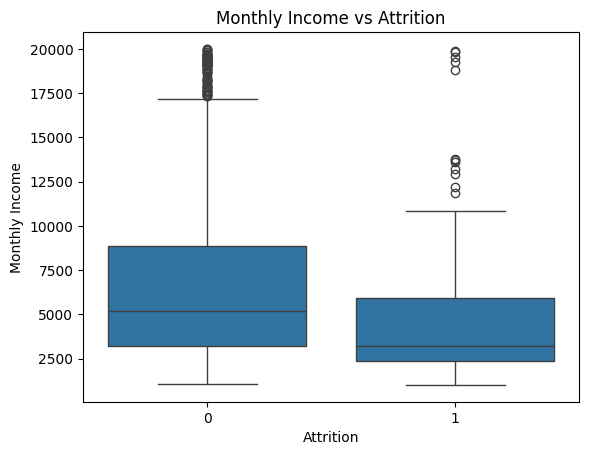

In [10]:
sns.boxplot(y=data.MonthlyIncome, x=data.Attrition)
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()

Удалим слишком большие выбросы:

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

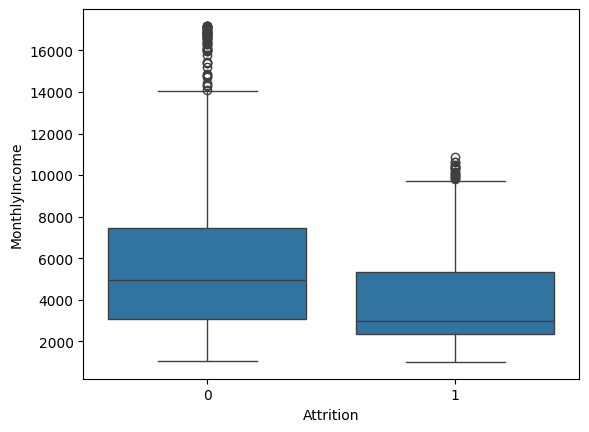

In [11]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

data_clean = data.groupby('Attrition').apply(
    lambda x: remove_outliers_iqr(x, 'MonthlyIncome')
).reset_index(drop=True)

sns.boxplot(y='MonthlyIncome', x='Attrition', data=data_clean)

In [12]:
data_clean.groupby("Attrition").MonthlyIncome.describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
0,1151.0,5977.929626,3718.790921,1051.0,3056.0,4930.0,7449.0,17181.0
1,225.0,4204.493333,2582.554774,1009.0,2362.0,2973.0,5346.0,10854.0


Статистический тест (t-тест):

In [13]:
left = data_clean.MonthlyIncome[(data_clean.Attrition==1)]
stayed = data_clean.MonthlyIncome[(data_clean.Attrition==0)]
stats.ttest_ind(left, stayed, nan_policy = "omit", equal_var=False)

TtestResult(statistic=-8.688958733468366, pvalue=7.798629829206156e-17, df=428.6727661340011)

In [14]:
print("Размер эффекта:",  stayed.mean() - left.mean())

Размер эффекта: 1773.4362930784828


Вывод: Мы отвергаем нулевую гипотезу, p-value < 0.05 (7.8*10^-17), средний доход оставшихся сотрудников статистически значимо выше, чем у тех, кто покинул компанию (разница тоже достаточно большая, если считать в долларах), такой результат наблюдается даже после удаления выбросов.

На начальном этапе работы с данными удалось выяснить, что текучесть кадров взаимосвязана с уровнем месячного дохода и тем, работал ли сотрудник сверхурочно.

Посмотрим на матрицу корреляции:

Основной вывод, который можно сделать, заключается в том, что коэффициент корреляции высок только там, где просто логична связь показателей: чем больше лет ты живёшь, тем больше лет ты работаешь, тем больше тебе платят, тем выше у тебя позиция и так далее. Неожиданных сильных связей не обнаружено.

In [15]:
data.drop(columns=['BusinessTravel', 'Department','EducationField', 'JobRole','MaritalStatus']).corr()

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,-0.159205,-0.001686,0.208034,0.010146,-0.036311,0.029820,0.509604,-0.004892,0.497855,...,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
Attrition,-0.159205,1.000000,0.077924,-0.031373,-0.103369,0.029453,-0.130016,-0.169105,-0.103481,-0.159840,...,0.002889,-0.045872,-0.137145,-0.171063,-0.059478,-0.063939,-0.134392,-0.160545,-0.033019,-0.156199
DistanceFromHome,-0.001686,0.077924,1.000000,0.021042,-0.016075,-0.001851,0.008783,0.005303,-0.003669,-0.017014,...,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.031373,0.021042,1.000000,-0.027128,-0.016547,0.042438,0.101589,-0.011296,0.094961,...,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,-0.103369,-0.016075,-0.027128,1.000000,0.000508,-0.008278,0.001212,-0.006784,-0.006259,...,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
Gender,-0.036311,0.029453,-0.001851,-0.016547,0.000508,1.000000,0.017960,-0.039403,0.033252,-0.031858,...,-0.013859,0.022868,0.012716,-0.046881,-0.038787,-0.002753,-0.029747,-0.041483,-0.026985,-0.030599
JobInvolvement,0.029820,-0.130016,0.008783,0.042438,-0.008278,0.017960,1.000000,-0.012630,-0.021476,-0.015271,...,-0.029071,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,-0.169105,0.005303,0.101589,0.001212,-0.039403,-0.012630,1.000000,-0.001944,0.950300,...,-0.021222,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281
JobSatisfaction,-0.004892,-0.103481,-0.003669,-0.011296,-0.006784,0.033252,-0.021476,-0.001944,1.000000,-0.007157,...,0.002297,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656
MonthlyIncome,0.497855,-0.159840,-0.017014,0.094961,-0.006259,-0.031858,-0.015271,0.950300,-0.007157,1.000000,...,-0.017120,0.025873,0.005408,0.772893,-0.021736,0.030683,0.514285,0.363818,0.344978,0.344079


### Размер выборки для эксперимента 1

Исследовательский вопрос: Уходят ли чаще сотрудники, которые работают сверхурочно, по сравнению с теми, кто не работает сверхурочно? Проверка различий между двумя долями (Attrition = 1 или 0 в группах OverTime = Yes/No).

In [16]:
over_t

,Stayed,Left
No overtime,944,110
Overtime,289,127


In [17]:
!pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


Способ 1: Использование функции proportion_effectsize из библиотеки statsmodels:

Для выбранного исследовательского вопроса рассчитан размер эффекта с помощью метрики Cohen’s h, которая отражает разницу между двумя пропорциями в стандартизированной форме. В качестве исходных данных использовались наблюдаемые доли увольнений в группах сотрудников с переработками и без них. Уровень значимости был выбран равным 0.05, мощность теста — 0.8. В качестве стандартного показателя разброса используется дисперсия бинарной переменной (уволился/не уволился), которая заложена в методе proportion_effectsize. На основании этих параметров рассчитан минимальный необходимый размер выборки на каждую группу и общий для двух групп.

In [18]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

p1 = 110 / 1054  # без переработок
p2 = 127 / 416   # с переработками

alpha = 0.05
power = 0.8

effect_size = proportion_effectsize(p2, p1)

analysis = NormalIndPower()
sample_size_per_group = analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha, ratio=1)

print(f"Размер эффекта (Cohen's h): {effect_size:.3f}")
print(f"Необходимый размер выборки на каждую группу: {np.ceil(sample_size_per_group):.0f}")
print(f"Общий размер выборки: {np.ceil(sample_size_per_group * 2):.0f}")


Размер эффекта (Cohen's h): 0.513
Необходимый размер выборки на каждую группу: 60
Общий размер выборки: 120


Способ 2: Расчёт «вручную» по классической формуле для двух пропорций:

В этом подходе размер эффекта также оценивался через Cohen’s h, но вручную на основе наблюдаемых долей увольнений в каждой группе. Разброс оценивался через биномиальную дисперсию: для каждой группы p*(1−p), а для проверки гипотезы использовалась общая дисперсия p0*(1-p0) (где p0 = (p1+p2)/2). Уровень значимости был установлен на 0.05, мощность теста — 0.8, соответствующие критические значения z были взяты из стандартного нормального распределения (z_alpha = 1.96, z_beta = 0.84). На основании этих параметров и классической формулы для двухвыборочного теста определён необходимый размер выборки на каждую группу.

Рассчитаем Cohen’s h для 2×2 таблицы:

In [19]:
no_overtime_stayed = 944
no_overtime_left = 110
overtime_stayed = 289
overtime_left = 127

no_overtime_total = no_overtime_stayed + no_overtime_left
overtime_total = overtime_stayed + overtime_left

p1 = no_overtime_left / no_overtime_total
p2 = overtime_left / overtime_total

p0 = (p1 + p2) / 2

cohen_h = np.sqrt((p1 - p2)**2 / (p0 * (1 - p0)))

print(f"Cohen’s h для пропорций: {cohen_h:.3f}")

Cohen’s h для пропорций: 0.498


По классификации Коэна: 0.498 близко к 0.5 — средний эффект.

In [20]:
alpha = 0.05
power = 0.8

z_alpha = 1.96
z_beta = 0.84

num = (z_alpha * np.sqrt(2 * p0 * (1 - p0)) + 
       z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
den = (p2 - p1) ** 2
sample_size_per_group = num / den

print(f"Необходимый размер выборки на каждую группу: {np.ceil(sample_size_per_group):.0f}")
print(f"Точное значение: {sample_size_per_group}")

Необходимый размер выборки на каждую группу: 63
Точное значение: 62.07091351249271


Вывод: Чтобы обнаружить такую разницу между долями увольнений при переработках и без них с мощностью 80% и уровнем значимости 0.05, достаточно примерно 63 наблюдений в каждой группе (всего около 126 участников). В наших данных респондентов в каждой группе было больше, так что мы мы можем доверять выводам о статистически значимой разнице (мы могли её найти и нашли). Значения размера выборки в двух способах примерно похожи (разница в 3 респондента).

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ff5c65e0-9edf-47b2-8d5a-439e7f5c1ece' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>